Model: "Interference_Transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 10, 10)]          0         
                                                                 
 dense_5 (Dense)             (None, 10, 64)            704       
                                                                 
 tf.__operators__.add_1 (TFO  (None, 10, 64)           0         
 pLambda)                                                        
                                                                 
 transformer_block_2 (Transf  (None, 10, 64)           83200     
 ormerBlock)                                                     
                                                                 
 transformer_block_3 (Transf  (None, 10, 64)           83200     
 ormerBlock)                                                     
                                          

118/118 [==============================] - 10s 26ms/step - loss: 0.2252 - accuracy: 0.3090 - val_loss: 0.1886 - val_accuracy: 0.3333
Epoch 2/50
118/118 [==============================] - 3s 22ms/step - loss: 0.1872 - accuracy: 0.3435 - val_loss: 0.1706 - val_accuracy: 0.3238
Epoch 3/50
118/118 [==============================] - 3s 21ms/step - loss: 0.1756 - accuracy: 0.3469 - val_loss: 0.1649 - val_accuracy: 0.3167
Epoch 4/50
118/118 [==============================] - 3s 21ms/step - loss: 0.1701 - accuracy: 0.3382 - val_loss: 0.1624 - val_accuracy: 0.3310
Epoch 5/50
118/118 [==============================] - 2s 20ms/step - loss: 0.1676 - accuracy: 0.3493 - val_loss: 0.1627 - val_accuracy: 0.3048
Epoch 6/50
118/118 [==============================] - 3s 22ms/step - loss: 0.1665 - accuracy: 0.3514 - val_loss: 0.1588 - val_accuracy: 0.3262
Epoch 7/50
118/118 [==============================] - 2s 20ms/step - loss: 0.1628 - accuracy: 0.3565 - val_loss: 0.1594 - val_accuracy: 0.3238
Epoch 8/5

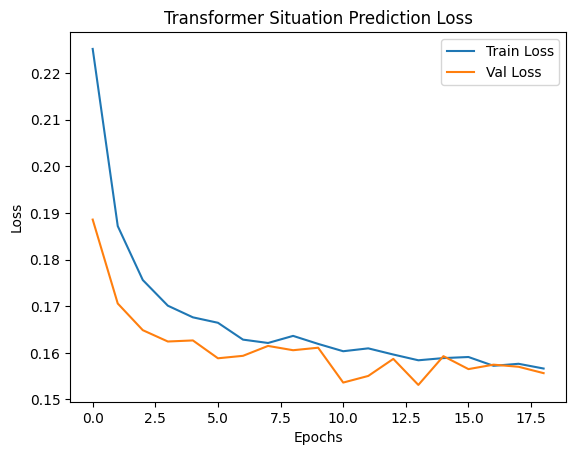

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ================= 1. 自定义 Transformer 层组件 =================

class TransformerBlock(Layer):
    """
    标准 Transformer 编码器块：实现多头自注意力与前馈神经网络
    """
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        # 多头自注意力机制 (Multi-head Self-Attention)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        # 前馈神经网络 (Position-wise Feed-Forward Network)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"), 
            Dense(embed_dim)
        ])
        # 层归一化与 Dropout 防止过拟合
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):
        # 1. 自注意力分支
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output) # 残差连接
        
        # 2. 前馈网络分支
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output) # 残差连接

# ================= 2. 构建 Transformer 预测模型 =================

def build_transformer_model(window_size=10, num_channels=10, embed_dim=64):
    """
    输入维度: [Batch, Window_Size, Num_Channels] (10个信道过去10个时刻的状态)
    输出维度: [Batch, Num_Channels] (预测下一时刻10个信道的占用概率)
    """
    inputs = Input(shape=(window_size, num_channels))
    
    # 1. 线性投影层：将 10 维信道特征映射到高维嵌入空间
    x = Dense(embed_dim)(inputs)
    
    # 2. 位置编码 (针对干扰时序的顺序性)
    # 此处使用简单的位置嵌入，Transformer 无法自动识别时序先后顺序
    positions = tf.range(start=0, limit=window_size, delta=1)
    pos_encoding = Embedding(input_dim=window_size, output_dim=embed_dim)(positions)
    x = x + pos_encoding 
    
    # 3. 堆叠 Transformer Encoder 块
    x = TransformerBlock(embed_dim=embed_dim, num_heads=4, ff_dim=128)(x)
    x = TransformerBlock(embed_dim=embed_dim, num_heads=4, ff_dim=128)(x)
    
    # 4. 全局特征聚合
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.2)(x)
    
    # 5. 输出层：使用 Sigmoid 激活函数输出每个信道被占用的概率
    outputs = Dense(num_channels, activation='sigmoid', name='occupancy_prediction')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name="Interference_Transformer")
    
    # 使用二元交叉熵损失函数，适合多标签分类任务
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ================= 3. 训练与评估流程 =================

def train_and_evaluate():
    data_path = "/root/autodl-tmp/validate/0218/Prediction/prediction_dataset_v2"
    
    # 1. 加载仿真数据集
    try:
        X_train = np.load(f"{data_path}/X_train.npy")
        y_train = np.load(f"{data_path}/y_train.npy")
        X_test = np.load(f"{data_path}/X_test.npy")
        y_test = np.load(f"{data_path}/y_test.npy")
    except FileNotFoundError:
        print("❌ 未找到数据集，请先运行仿真数据生成脚本！")
        return

    # 2. 初始化模型
    model = build_transformer_model(window_size=10, num_channels=10)
    model.summary()

    # 3. 设置训练回调 (保存最佳模型，防止过拟合)
    save_path = "./models/transformer_situation_model.h5"
    os.makedirs("./models", exist_ok=True)
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(save_path, save_best_only=True, monitor='val_loss')
    ]

    # 4. 启动训练
    print("\n🔥 正在启动 Transformer 干扰态势学习...")
    history = model.fit(
        X_train, y_train, 
        validation_split=0.1, 
        epochs=50, 
        batch_size=32, 
        callbacks=callbacks, 
        verbose=1
    )

    # 5. 模型评估与准确率证明
    preds = model.predict(X_test)
    # 将概率转为 0/1 判定
    y_pred_bin = (preds > 0.5).astype(int)
    
    # 计算全信道联合预测准确率 (10个信道必须全部预测正确才算该时刻预测成功)
    correct_moments = [np.array_equal(y_test[i], y_pred_bin[i]) for i in range(len(y_test))]
    joint_acc = np.mean(correct_moments) * 100

    print("\n" + "="*45)
    print(f"✅ 干扰态势预测评估完成")
    print(f"📊 历史窗口长度: 10 (时隙)")
    print(f"🎯 全信道联合预测准确率: {joint_acc:.2f}%")
    print(f"💡 预测结果已准备好对接强化学习状态空间 (State)")
    print("="*45)

    # 6. 绘制 Loss 曲线用于论文展示
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Transformer Situation Prediction Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.show()

if __name__ == "__main__":
    import os
    train_and_evaluate()

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ================= 1. 环境配置与路径修复 =================
# 建议使用绝对路径以确保万无一失
DATA_DIR = "/root/autodl-tmp/validate/0218/Prediction/situation_data_v1"
MODEL_DIR = "./models1"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ================= 2. 增强型数据生成逻辑 (集成) =================

def ensure_data_exists():
    """检查数据文件，如果缺失则重新生成"""
    required_files = ["X_train.npy", "y_train.npy", "X_val.npy", "y_val.npy", "X_test.npy", "y_test.npy"]
    exists = all(os.path.exists(os.path.join(DATA_DIR, f)) for f in required_files)
    
    if not exists:
        print("📁 正在重新生成增强型态势数据集...")
        TOTAL_STEPS = 12000
        NUM_CHANNELS = 10
        WINDOW_SIZE = 12
        
        data = []
        sweep_ch = 0
        for t in range(TOTAL_STEPS):
            occ = np.zeros(NUM_CHANNELS)
            # 模拟扫频规律 (模式1)
            if t % 4000 < 1200:
                if t % 4 == 0: sweep_ch = (sweep_ch + 1) % NUM_CHANNELS
                occ[sweep_ch] = 1.0
            # 模拟动态跳频 (模式2)
            elif t % 4000 < 2400:
                hop_pattern = [1, 4, 2, 7, 3, 9]
                curr_ch = hop_pattern[(t // 8) % len(hop_pattern)]
                occ[curr_ch] = 1.0
            # 模拟混合干扰 (模式3)
            else:
                occ[5] = 1.0
                if t % 20 < 5: occ[2] = 1.0
                if np.random.rand() > 0.85: occ[np.random.randint(0, 10)] = 1.0
            data.append(occ)
        
        raw_data = np.array(data)
        X, y = [], []
        for i in range(len(raw_data) - WINDOW_SIZE):
            X.append(raw_data[i : i + WINDOW_SIZE])
            y.append(raw_data[i + WINDOW_SIZE])
        X, y = np.array(X), np.array(y)
        
        # 严格按时间轴顺序划分，防止数据泄露
        X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, shuffle=False)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)
        
        np.save(f"{DATA_DIR}/X_train.npy", X_train)
        np.save(f"{DATA_DIR}/y_train.npy", y_train)
        np.save(f"{DATA_DIR}/X_val.npy", X_val)
        np.save(f"{DATA_DIR}/y_val.npy", y_val)
        np.save(f"{DATA_DIR}/X_test.npy", X_test)
        np.save(f"{DATA_DIR}/y_test.npy", y_test)
        print(f"✅ 数据集已成功写入: {DATA_DIR}")
    else:
        print("✅ 检测到完整数据集，跳过生成步骤。")

# ================= 3. 1D-CNN + Transformer 模型架构 =================

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation="gelu"), Dense(embed_dim)])
        self.layernorm1, self.layernorm2 = LayerNormalization(epsilon=1e-6), LayerNormalization(epsilon=1e-6)
        self.dropout1, self.dropout2 = Dropout(rate), Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_hybrid_model(window_size=12, num_channels=10, embed_dim=128):
    inputs = Input(shape=(window_size, num_channels))
    # CNN 预处理：提取局部特征
    c1 = Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    c2 = Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    x = Concatenate()([c1, c2])
    x = Dense(embed_dim)(x)
    
    # 位置编码
    positions = tf.range(start=0, limit=window_size, delta=1)
    pos_encoding = Embedding(input_dim=window_size, output_dim=embed_dim)(positions)
    x = x + pos_encoding

    # Transformer 核心
    x = TransformerBlock(embed_dim, num_heads=8, ff_dim=256)(x)
    x = TransformerBlock(embed_dim, num_heads=8, ff_dim=256)(x)
    
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_channels, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ================= 4. 运行训练与评估 =================

def run_pipeline():
    ensure_data_exists()
    
    # 加载数据
    X_train = np.load(f"{DATA_DIR}/X_train.npy")
    y_train = np.load(f"{DATA_DIR}/y_train.npy")
    X_val = np.load(f"{DATA_DIR}/X_val.npy")
    y_val = np.load(f"{DATA_DIR}/y_val.npy")
    X_test = np.load(f"{DATA_DIR}/X_test.npy")
    y_test = np.load(f"{DATA_DIR}/y_test.npy")

    model = build_hybrid_model()
    
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint(f"{MODEL_DIR}/best_hybrid_situation.h5", save_best_only=True)
    ]

    print("\n🔥 启动混合架构训练...")
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), 
                        epochs=60, batch_size=64, callbacks=callbacks, verbose=1)

    # 结果评估
    preds = (model.predict(X_test) > 0.5).astype(int)
    joint_acc = np.mean([np.array_equal(y_test[i], preds[i]) for i in range(len(y_test))])
    print(f"\n🎯 最终全信道联合预测准确率: {joint_acc*100:.2f}%")

if __name__ == "__main__":
    run_pipeline()

2026-02-24 22:37:10.079821: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


📁 正在重新生成增强型态势数据集...
✅ 数据集已成功写入: /root/autodl-tmp/validate/0218/Prediction/situation_data_v1


2026-02-24 22:37:12.357990: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22182 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:27:00.0, compute capability: 8.9



🔥 启动混合架构训练...
Epoch 1/60


2026-02-24 22:37:16.556101: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-02-24 22:37:16.771948: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-02-24 22:37:16.941257: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7f84d405f6a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-24 22:37:16.941282: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-02-24 22:37:16.946942: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-24 22:37:17.122733: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the p

150/150 [==============================] - 11s 15ms/step - loss: 0.0940 - accuracy: 0.8198 - val_loss: 0.0479 - val_accuracy: 0.8874 - lr: 0.0010
Epoch 2/60
150/150 [==============================] - 2s 11ms/step - loss: 0.0413 - accuracy: 0.8940 - val_loss: 0.0381 - val_accuracy: 0.9016 - lr: 0.0010
Epoch 3/60
150/150 [==============================] - 2s 11ms/step - loss: 0.0332 - accuracy: 0.9097 - val_loss: 0.0348 - val_accuracy: 0.9016 - lr: 0.0010
Epoch 4/60
150/150 [==============================] - 2s 11ms/step - loss: 0.0314 - accuracy: 0.9145 - val_loss: 0.0335 - val_accuracy: 0.9024 - lr: 0.0010
Epoch 5/60
150/150 [==============================] - 2s 10ms/step - loss: 0.0320 - accuracy: 0.9111 - val_loss: 0.0366 - val_accuracy: 0.9475 - lr: 0.0010
Epoch 6/60
150/150 [==============================] - 1s 10ms/step - loss: 0.0328 - accuracy: 0.9048 - val_loss: 0.0358 - val_accuracy: 0.9008 - lr: 0.0010
Epoch 7/60
150/150 [==============================] - 2s 11ms/step - loss: